In [1]:
# /// script
# requires-python = ">=3.13"
# dependencies = [
#     "careamics[examples]>=0.3.0, <0.4.0",
# ]
# [tool.uv.sources]
# careamics = {git = "https://github.com/CAREamics/careamics", branch = "dev/ome_zarr_sister"}
# ///

<img src="https://careamics.github.io/latest/images/banner_careamics_large.png">

# Patching, data loading, OME-NGFF and Noise2Void

Updated 30.09.26

In this notebook, we explore CAREamics data filtering, use an OME-NGFF Zarr file, and
train Noise2Void on it.


<div style="
  background: #fff8db;
  border-left: 6px solid #e2b200;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #8a6a00;
">
  <strong style="color: #8a6a00;">Important</strong><br>
  
  This notebook is using an experimental branch for OME-NGFF at the time of the writing, API, implementation
  and features might change in the future.
</div>


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pooch
from scipy import ndimage as ndi
import zarr
import yaozarrs

from careamics import CAREamist
from careamics.config import create_advanced_n2v_config

from careamics.lightning.data import CareamicsDataModule
from careamics.plotting import plot_loss
from careamics.config.data.patch_filter import MaxPatchFilterConfig
from careamics.dataset.patch_filter import MaxPatchFilter

SEED = 24

# 1 - Example data

The example data is extracted from [10.5281/zenodo.22078388](https://doi.org/10.5281/zenodo.22078388). It is a small excerpt
from a larger experiment imaging 3D time-lapse light-sheet microscopy.

In [3]:
def download_data() -> Path:
    """Download example data.

    Returns
    -------
    Path
        Path to data.
    """
    root = Path("") / "data"
    root.mkdir(exist_ok=True)

    file_list = pooch.retrieve(
        "https://zenodo.org/records/22078388/files/001-mini.zip?download=1",
        known_hash="a253ebdda4300231c5a890908158cda8efe47cf8de9fddb101ae1eb6c10b824d",
        processor=pooch.Unzip(),
        path=root,
    )

    for f in file_list:
        if f.endswith("raw.ome.zarr/zarr.json"):
            return Path(f).parent

    return f

file_path = download_data()

In [4]:
# Check out Zarr file
z = zarr.open(file_path)
print(z.tree())

# Validate that it is OME-NGFF compliant (no error raised)
_ = yaozarrs.validate_zarr_store(file_path)

/
├── 0 (5, 2, 76, 389, 610) uint16
├── 1 (5, 2, 76, 194, 305) uint16
├── 2 (5, 2, 76, 96, 152) uint16
├── 3 (5, 2, 76, 47, 76) uint16
└── 4 (5, 2, 76, 23, 38) uint16



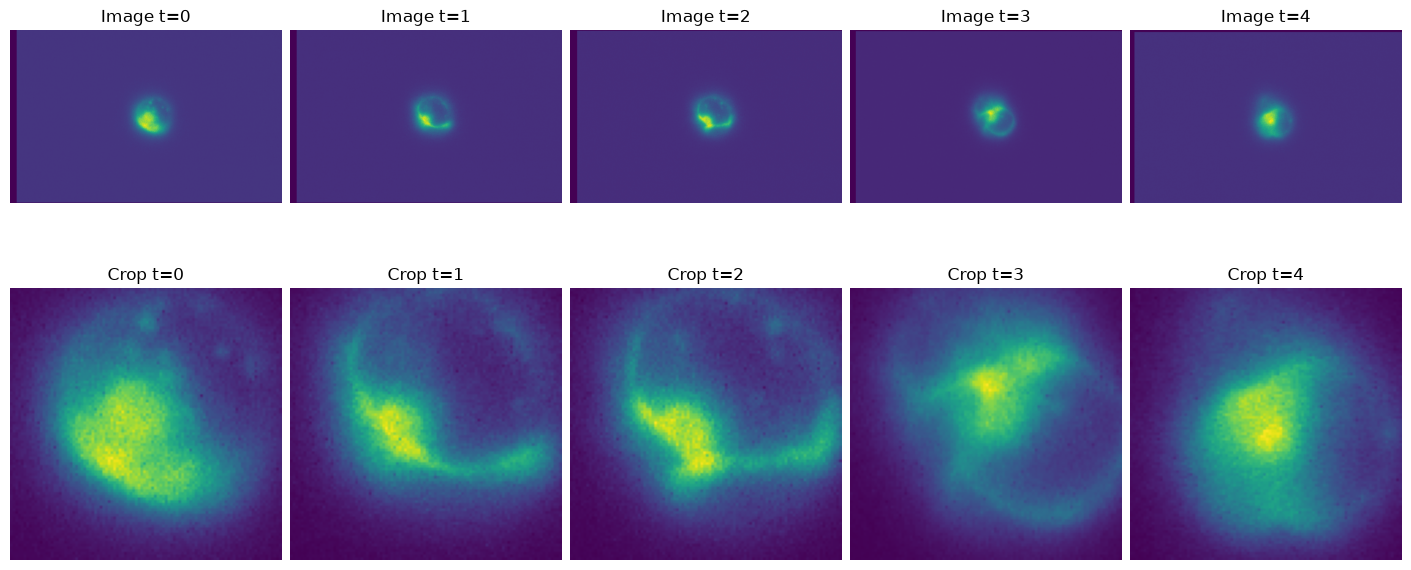

In [5]:
scale = "0"
chan = 0
z_mid = 38
xy_crop = (slice(150, 250), slice(265, 365))

img = z[scale][:, chan, z_mid]

fig, axes = plt.subplots(2, img.shape[0], figsize=(14,6), constrained_layout=True)

for t in range(img.shape[0]):
    axes[0, t].imshow(img[t])
    axes[0, t].axis("Off")
    axes[0, t].set_title(f"Image t={t}")

    axes[1, t].imshow(img[t][*xy_crop])
    axes[1, t].axis("Off")
    axes[1, t].set_title(f"Crop t={t}")


## 2 - Excluding patches from training (masking and filtering)

In many microscopy datasets, not all image areas are equally useful for training. In this light-sheet data the sample only covers a part of the field of view and the rest is background. Other datasets might have saturated areas, stitching artefacts or other corrupted areas. 

We can exclude these regions so:
- training time is spent on most informative patches
- the network is not biased towards background - a network that mostly sees background during training might get very good at denoising it and not the sample

We provide two mechanisms:
- patch filtering - CAREamics computes statistics (e.g. maximum intensity) for each patch and skips ones that are below a threshold
- masking - you provide a binary mask of the region to train on

Both apply for training only and not during prediction, it runs on the whole image. 
 

### 2.1 Patch filtering

With patch filtering, CAREamics computes a statistic for each patch and compares it to a
threshold. Three statistics are available:

- Maximum intensity (`MaxPatchFilterConfig`)
- Shannon entropy (`ShannonPatchFilterConfig`)
- Mean and standard deviation (`MeanStdPatchFilterConfig`)

Here we use the maximum intensity filter, which fits the data - a bright sample on a dark
background.

<div style="
  background: #f3f4f6;
  border-left: 6px solid #6b7280;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #374151;
">
  <strong>Note</strong><br>

  Filtered patches are not removed completely: they are still selected with a small
  probability (10% by default, parameter `filtered_patch_prob`). The network still sees some
  background, which it will also have to denoise at prediction time.
</div>

To keep the demo fast, we use a lower resolution level of the OME-Zarr. OME-Zarr files store
the same image at several resolutions (see the `z.tree()` output above): level `"0"` is the
full resolution, and each following level is half the size in XY. We use level `"1"`.

Shape (76, 194, 305)


Text(0, 0.5, 'threshold')

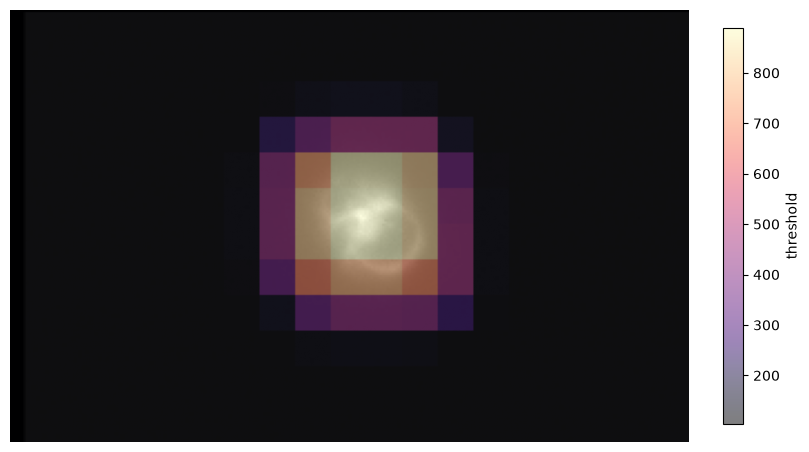

In [6]:
# Lower resolution level used in the rest of the notebook (half size in XY)
level = "1"

# Compute the filter map of one time point (ZYX), using the training patch size
img = z[level][3, chan]
print(f"Shape {img.shape}")

max_filter_map = MaxPatchFilter.filter_map(img, patch_size=(4, 16, 16))

# Display the middle Z slice
fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
ax.imshow(img[z_mid], "gray")
ax.axis("Off")
m = ax.imshow(max_filter_map[z_mid], "magma", alpha=0.5)
cbar = plt.colorbar(m, ax=ax, shrink=0.5)
cbar.ax.set_ylabel("threshold")

The filter map helps to choose a threshold. The map depends on the patch size, so compute it with the same patch size as the one used for training. 

We can now pass the filter to the configuration:

In [7]:
config = create_advanced_n2v_config(
    experiment_name="filtering_demo",
    data_type="zarr",
    axes="TCZYX",
    patch_size=(4, 64, 64),
    batch_size=32,
    num_epochs=5,
    num_steps=100,
    channels=[0],
    # pre-computed, remove and see log to compute them again
    normalization_params={"input_means": [105.27], "input_stds": [31.41]},
    patch_filter_config=MaxPatchFilterConfig(
        threshold=600, filtered_patch_prob=0.025
    ),
)

Let's look at a sample of the training patches (mean projection along Z).

Filtering background patches with filtering function max: 100%|█████████████████████████████████████| 5/5 [00:24<00:00,  4.87s/it]
Found 1086 background regions. Number of patches has been reduced to 314 from 1375.


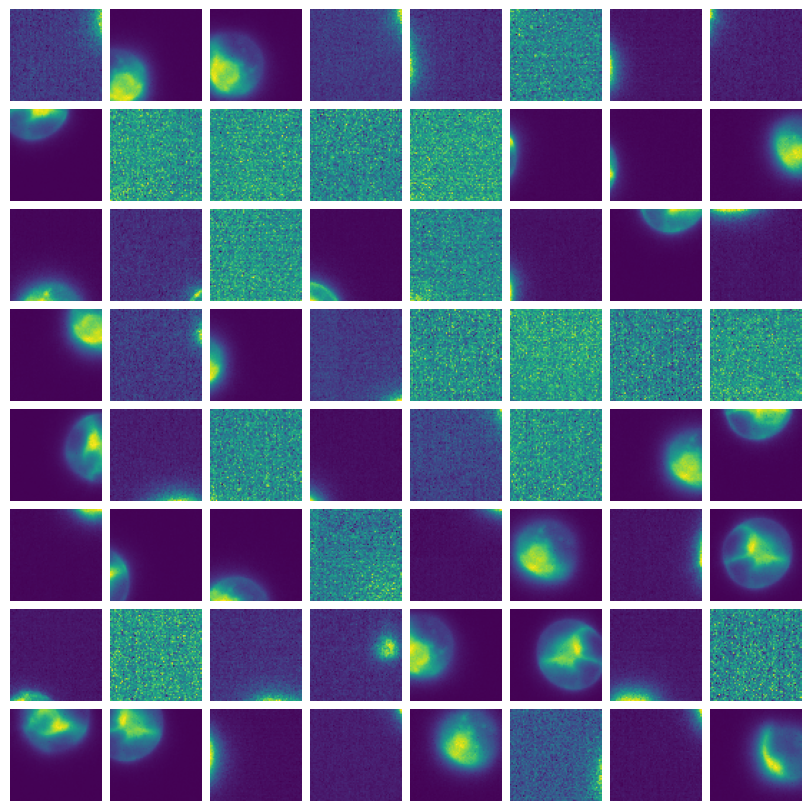

In [8]:
# A URI pointing to a single level of the OME-Zarr selects that resolution level
level_uri = f"file://{file_path.resolve()}/{level}"

# note: filtering is computed over the whole dataset when setting up, this takes ~40 s
datamodule = CareamicsDataModule(
    data_config=config.data_config,
    train_data=level_uri,
)
datamodule.setup("fit")
train_dataset = datamodule.train_dataloader().dataset

N = 8
fig, axes = plt.subplots(N, N, figsize=(8, 8), constrained_layout=True)
for k, ax in enumerate(axes.flat):
    patch = train_dataset[k][0].data.squeeze()
    ax.imshow(patch.mean(axis=0))
    ax.axis("Off")


### 2.2 Masking

With masking, you decide yourself which regions to train on by providing a binary mask. The mask can come from
anything, e.g. a segmentation, a manual annotation or a simple threshold. It must have the same shape and axes as the data, and be in the same format (here, a Zarr array).

Here, we create a rough foreground mask by blurring the images and thresholding them.

In [9]:
img = z[level][:, chan]  # TZYX

mask = np.stack([
    ndi.gaussian_filter(img[t].astype(np.float32), sigma=(2, 8, 8)) > 103
    for t in range(img.shape[0])
])
print(f"Mask shape {mask.shape}, {mask.mean():.1%} of the pixels are True")

Mask shape (5, 76, 194, 305), 3.0% of the pixels are True


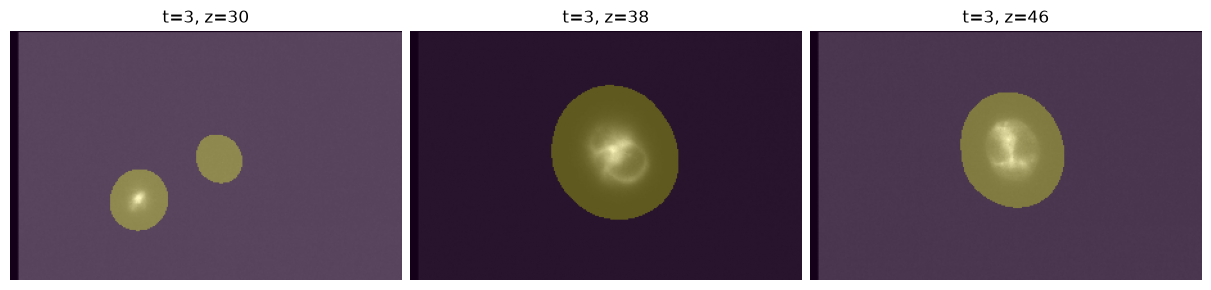

In [10]:
# Display the mask over a few Z slices of one time point
t = 3
z_slices = [z_mid - 8, z_mid, z_mid + 8]

fig, axes = plt.subplots(1, len(z_slices), figsize=(12, 4), constrained_layout=True)
for ax, z_slice in zip(axes, z_slices):
    ax.imshow(img[t, z_slice], "gray")
    ax.imshow(mask[t, z_slice], alpha=0.3)
    ax.set_title(f"t={t}, z={z_slice}")
    ax.axis("Off")

In [11]:
# The mask needs the same axes as the data (TCZYX), so we add the channel axis
mask_path = Path("") / "mask" / "mask.zarr"
zarr.create_array(store=mask_path, data=mask[:, np.newaxis], overwrite=True)

<Array file://mask/mask.zarr shape=(5, 1, 76, 194, 305) dtype=bool>

The mask is passed together with the training data. To look at its effect alone, we create a
configuration without patch filtering:

Filtering background patches with provided mask: 100%|██████████████████████████████████████████████| 5/5 [00:07<00:00,  1.58s/it]
Found 1040 background regions. Number of patches has been reduced to 440 from 1375.


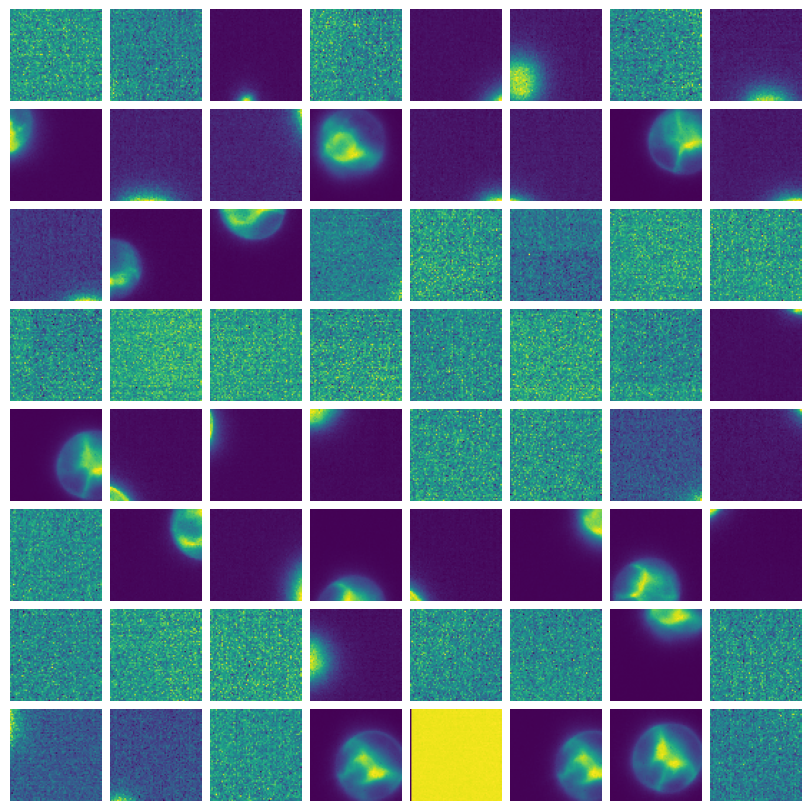

In [12]:
mask_config = create_advanced_n2v_config(
    experiment_name="masking_demo",
    data_type="zarr",
    axes="TCZYX",
    patch_size=(4, 64, 64),
    batch_size=32,
    num_epochs=5,
    num_steps=100,
    channels=[0],
    normalization_params={"input_means": [105.27], "input_stds": [31.41]},
)

datamodule = CareamicsDataModule(
    data_config=mask_config.data_config,
    train_data=level_uri,
    train_data_mask=mask_path,
)
datamodule.setup("fit")
train_dataset = datamodule.train_dataloader().dataset

N = 8
fig, axes = plt.subplots(N, N, figsize=(8, 8), constrained_layout=True)
for k, ax in enumerate(axes.flat):
    patch = train_dataset[k][0].data.squeeze()
    ax.imshow(patch.mean(axis=0))
    ax.axis("Off")

<div style="
  background: #f3f4f6;
  border-left: 6px solid #6b7280;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #374151;
">
  <strong>Note</strong><br>

  Like filtering, masking is not all-or-nothing. A sampling region is kept if enough of its
  pixels are <code>True</code> in the mask and masked-out regions are still
  selected with a small probability.
</div>

## 3 - Training Noise2Void on a Zarr

CAREamics supports several [file formats](https://careamics.github.io/latest/content/guides/current/data/), but not OME-NGFF files (yet!). In this experimental branch, we have added support for OME-NGFF compatible Zarr files. By default, CAREamics uses the full resolution level `"0"`; to use another level, pass a URI pointing to that level, as we did above.

We now train Noise2Void on level `"1"`, using both the patch filter from section 2.1 and the
mask from section 2.2.

In [13]:
exp = "n2v_lightsheet_denoising"
root = Path("") / exp
root.mkdir(exist_ok=True)

config = create_advanced_n2v_config(
    experiment_name=exp,
    data_type="zarr",
    axes="TCZYX",
    patch_size=(4, 64, 64),
    # because we are training 3D, this may take a while
    # so we choose lower settings for the sake of the demonstration
    batch_size=16,
    num_epochs=5,
    num_steps=100,
    channels=[0], # only train on the first channel
    normalization_params={"input_means": [105.27], "input_stds": [31.41]}, # pre-computed, remove and see log
    patch_filter_config=MaxPatchFilterConfig(threshold=600, filtered_patch_prob=0.025), # section 2.1
)
careamist = CAREamist(config=config, work_dir=root)
careamist.train(
    train_data=level_uri,
    filtering_mask=mask_path, # section 2.2
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 113737358
You are using a CUDA device ('NVIDIA A40-24Q') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Filtering background patches with filtering function max: 100%|█████████████████████████████████████| 5/5 [00:24<00:00,  4.89s/it]
Found 1086 background regions. Number of patches has been reduced to 314 from 1375.
Filtering background patches with provided mask: 100%|████████████████████████████████████████████

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ UNet             │  997 K │ train │     0 │
│ 1 │ metrics │ MetricCollection │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 997 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 997 K                                                                                                
Total estimated model params size (MB): 3.991                                                                      
Modules in train mode: 41                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |                                                                                          | …

/localscratch/uv/cache/environments-v2/juv-tmp-wxyxn5eu-dfbde302553bca4a/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/localscratch/uv/cache/environments-v2/juv-tmp-wxyxn5eu-dfbde302553bca4a/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (25) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


The figure was saved at /home/vera.galinova/dev/careamics-workshops/n2v_filtering_zarr/n2v_lightsheet_denoising/results/loss.png


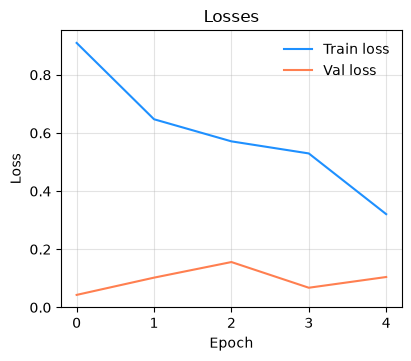

In [14]:
# Plot losses and save the figure to disk
results = root / "results"
results.mkdir(exist_ok=True, parents=True)

plot_loss(
    careamist.get_losses(),
    plot_learning_rate=False,
    plot_metrics=False,
    save_path=results / "loss.png"
)



In [15]:
# Prediction directly to disk using tiling
careamist.predict_to_disk(
    pred_data=level_uri,
    batch_size=4,
    tile_size=(8, 128, 128),
    tile_overlap=(2, 32, 32),
)

/localscratch/uv/cache/environments-v2/juv-tmp-wxyxn5eu-dfbde302553bca4a/lib/python3.13/site-packages/pydantic/main.py:112: UserWarning: Warning: Batch normalization is used with batch size 4. We advise using a batch size of at least 8 when using batch normalization, as smaller batch sizes may be unreliable. Consider increasing the batch size or disabling batch normalization in the algorithm `model` parameter.
  'validate_assignment': lambda model, name, val: model.__pydantic_validator__.validate_assignment(model, name, val),  # pyright: ignore[reportAssignmentType]
Creating prediction output directory: '/home/vera.galinova/dev/careamics-workshops/n2v_filtering_zarr/n2v_lightsheet_denoising/predictions'
Restoring states from the checkpoint path at /home/vera.galinova/dev/careamics-workshops/n2v_filtering_zarr/n2v_lightsheet_denoising/checkpoints/n2v_lightsheet_denoising_0/n2v_lightsheet_denoising_last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoi

Predicting: |                                                                                               | …

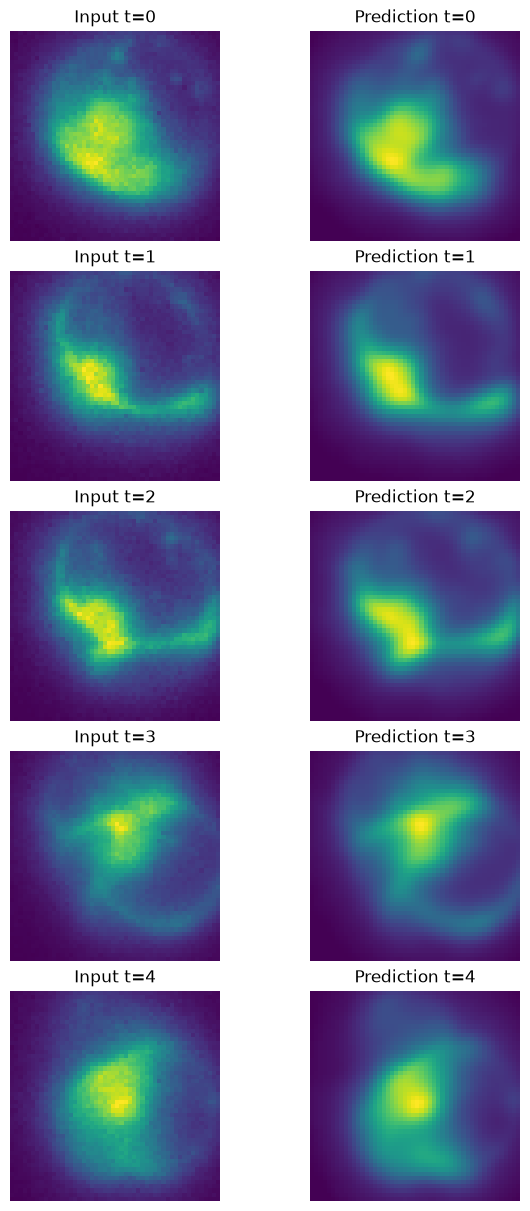

In [16]:
# Check that the output exists and is OME-NGFF compliant
pred_path = root / "predictions" / "raw_output.ome.zarr"
assert pred_path.exists()
_ = yaozarrs.validate_zarr_store(pred_path)

# the prediction keeps the name of the level it was computed on
z_pred = zarr.open(pred_path)
img = z[level][:, chan, z_mid]
pred = z_pred[level][:, 0, z_mid]
assert img.shape == pred.shape

# same crop as in section 1, at half resolution
xy_crop_level = (slice(75, 125), slice(132, 182))

fig, axes = plt.subplots(img.shape[0], 2, figsize=(6, 12), constrained_layout=True)
for t in range(img.shape[0]):
    axes[t, 0].imshow(img[t][*xy_crop_level])
    axes[t, 0].axis("Off")
    axes[t, 0].set_title(f"Input t={t}")

    axes[t, 1].imshow(pred[t][*xy_crop_level])
    axes[t, 1].axis("Off")
    axes[t, 1].set_title(f"Prediction t={t}")

## Optional exercises

<div style="
  background: #accffb;
  border-left: 6px solid #2f80ed;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #21457f;
">
  <strong style="color: #21457f;">Optional exercise: longer training</strong><br>

  Train for longer.
</div>

<div style="
  background: #accffb;
  border-left: 6px solid #2f80ed;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #21457f;
">
  <strong style="color: #21457f;">Optional exercise: filtering and masking</strong><br>

  Compare training with and without filtering and masking, using the same number of steps per epochs
  (parameter `num_steps` in the configuration).
</div>

<div style="
  background: #accffb;
  border-left: 6px solid #2f80ed;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #21457f;
">
  <strong style="color: #21457f;">Optional exercise: use custom formats with CAREamics</strong><br>

  Try the [tutorial on custom formats](https://careamics.github.io/latest/content/guides/tutorials/custom_data/).
</div>

<div style="
  background: #accffb;
  border-left: 6px solid #2f80ed;
  padding: 12px 16px;
  border-radius: 8px;
  margin: 12px 0;
  color: #21457f;
">
  <strong style="color: #21457f;">Optional exercise: advanced custom loading with CAREamics</strong><br>

  For more advanced data loading, CAREamics has another mechanism to allow you to define
  how to load data. Try the [tutorial on custom ImageStack](https://careamics.github.io/latest/content/guides/tutorials/implementing_an_image_stack/).
</div>
